In [2]:
import numpy as np
from qiskit.circuit.library import n_local

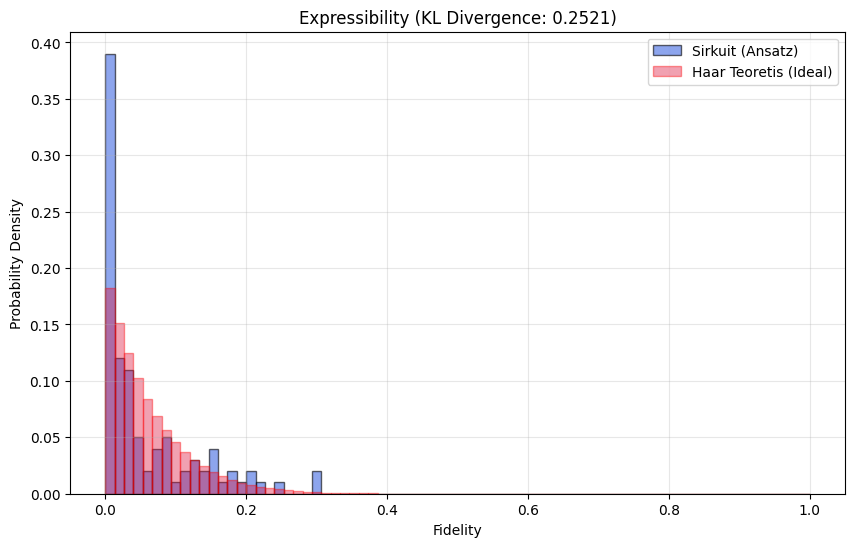

Nilai Expressibility (Semakin kecil semakin baik/Haar-like): 0.2521


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from scipy.special import rel_entr
from qiskit.circuit import QuantumCircuit


def gen_circuit(num_qubit=4):
    ansatz = n_local(
            num_qubits=num_qubit,
            rotation_blocks=['ry'],
            entanglement_blocks='cx',
            entanglement='linear',
            reps=2,
            insert_barriers=True
        )
    return ansatz, ansatz.parameters

def compute_expressibility(num_qubits, num_samples=100, num_bins=75):
    # 1. Inisialisasi Sirkuit
    np.random.seed(42)
    qc, num_params = gen_circuit(num_qubits)
    N = 2**num_qubits # Dimensi Hilbert Space
    
    fidelities = []
    
    # 2. Sampling Fidelity dari Sirkuit
    for _ in range(num_samples):
        # Ambil dua set parameter acak secara seragam [-pi, pi]
        theta1 = np.random.uniform(-5, 5, len(num_params))
        theta2 = np.random.uniform(-5, 5, len(num_params))
        
        # Bangun statevector untuk masing-masing parameter
        sv1 = Statevector(qc.assign_parameters(theta1))
        sv2 = Statevector(qc.assign_parameters(theta2))
        
        # Hitung Fidelity: F = |<psi1|psi2>|^2
        fidelity = np.abs(sv1.inner(sv2))**2
        fidelities.append(fidelity)
    
    # 3. Buat Histogram untuk Sirkuit
    bin_edges = np.linspace(0, 1, num_bins + 1)
    P_circuit, _ = np.histogram(fidelities, bins=bin_edges, density=True)
    # Normalisasi agar total area = 1 (untuk probabilitas bin)
    P_circuit = (P_circuit + 1e-10) / np.sum(P_circuit + 1e-10)
    
    # 4. Hitung Histogram Teoretis Haar
    # Menggunakan rumus integrasi yang kita bahas sebelumnya
    P_haar = []
    for i in range(num_bins):
        low = bin_edges[i]
        high = bin_edges[i+1]
        prob = (1 - low)**(N-1) - (1 - high)**(N-1)
        P_haar.append(prob)
    P_haar = np.array(P_haar)
    
    # 5. Hitung KL Divergence (Expressibility)
    # Gunakan sedikit epsilon agar tidak ada pembagian dengan nol
    kl_div = sum(rel_entr(P_circuit, P_haar))
    
    return fidelities, P_haar, bin_edges, kl_div

# Eksekusi untuk 4 Qubits
num_qubits = 4
fidel_list, p_haar, bins, expr_value = compute_expressibility(num_qubits)

# --- VISUALISASI ---
plt.figure(figsize=(10, 6))
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 1.0 / len(p_haar) # Lebar tiap bar


# Histogram Sirkuit (Hasil Sampling)
# Kita hitung dulu histogram sirkuit secara eksplisit agar bisa diplot dengan plt.bar
p_circuit, _ = np.histogram(fidel_list, bins=bins)
p_circuit = p_circuit / np.sum(p_circuit) # Normalisasi jadi probabilitas

plt.bar(bin_centers, p_circuit, width=width, alpha=0.6, 
        label='Sirkuit (Ansatz)', color='royalblue', edgecolor='black')


# Plot Distribusi Haar (Garis Teoretis)
plt.bar(bin_centers, p_haar, width=width, alpha=0.4, 
        label='Haar Teoretis (Ideal)', color='crimson', edgecolor='red')

plt.title(f'Expressibility (KL Divergence: {expr_value:.4f})')
plt.xlabel('Fidelity')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Nilai Expressibility (Semakin kecil semakin baik/Haar-like): {expr_value:.4f}")

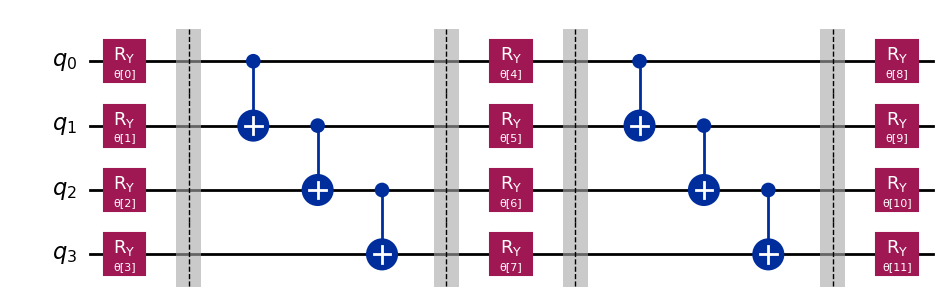

In [5]:
ansatz, _ = gen_circuit(4)
ansatz.draw("mpl")

In [5]:
num_qubits = 4
num_samples = 1000
num_bins=75
# 1. Inisialisasi Sirkuit
qc, num_params = gen_circuit(num_qubits)
N = 2**num_qubits # Dimensi Hilbert Space

fidelities = []

# 2. Sampling Fidelity dari Sirkuit
for _ in range(num_samples):
    # Ambil dua set parameter acak secara seragam [-pi, pi]
    theta1 = np.random.uniform(-np.pi, np.pi, len(num_params))
    theta2 = np.random.uniform(-np.pi, np.pi, len(num_params))
    
    # Bangun statevector untuk masing-masing parameter
    sv1 = Statevector(qc.assign_parameters(theta1))
    sv2 = Statevector(qc.assign_parameters(theta2))
    
    # Hitung Fidelity: F = |<psi1|psi2>|^2
    fidelity = np.abs(sv1.inner(sv2))**2
    fidelities.append(fidelity)

# 3. Buat Histogram untuk Sirkuit
bin_edges = np.linspace(0, 1, num_bins + 1)
P_circuit, _ = np.histogram(fidelities, bins=bin_edges, density=True)
# Normalisasi agar total area = 1 (untuk probabilitas bin)
P_circuit /= np.sum(P_circuit)

# 4. Hitung Histogram Teoretis Haar
# Menggunakan rumus integrasi yang kita bahas sebelumnya
P_haar = []
for i in range(num_bins):
    low = bin_edges[i]
    high = bin_edges[i+1]
    prob = (1 - low)**(N-1) - (1 - high)**(N-1)
    P_haar.append(prob)
P_haar = np.array(P_haar)

# 5. Hitung KL Divergence (Expressibility)
# Gunakan sedikit epsilon agar tidak ada pembagian dengan nol
kl_div = sum(rel_entr(P_circuit, P_haar))

In [13]:
kl_div

64.76232170304469